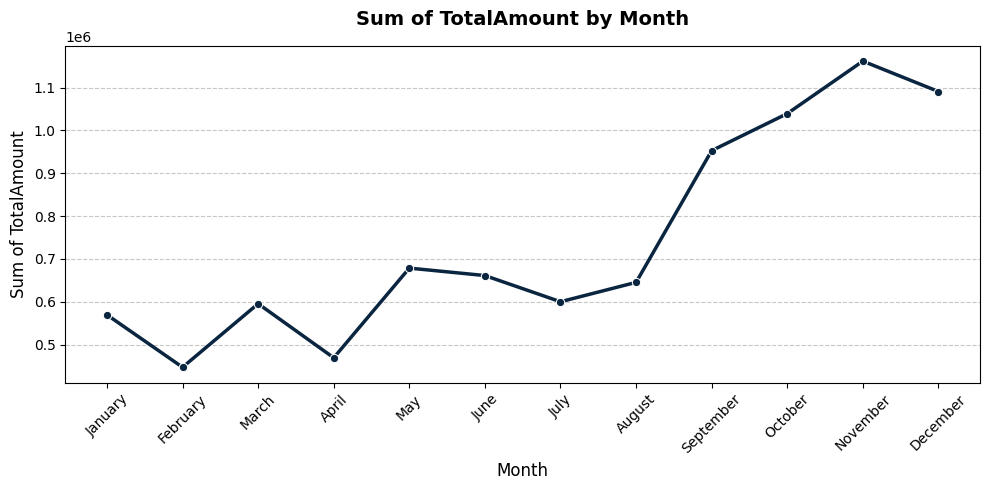

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('cleaned_ecommerce.csv')

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


df['Month'] = df['InvoiceDate'].dt.strftime('%B')
months_order = ['January', 'February', 'March', 'April', 'May', 'June',
                'July', 'August', 'September', 'October', 'November', 'December']

monthly_sales = df.groupby('Month')['TotalAmount'].sum().reindex(months_order).reset_index()


plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_sales, x='Month', y='TotalAmount', marker='o', color='#0A2540', linewidth=2.5)

plt.title('Sum of TotalAmount by Month', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Sum of TotalAmount', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()


plt.savefig('monthly_sales_trend.png', dpi=300)
plt.show()

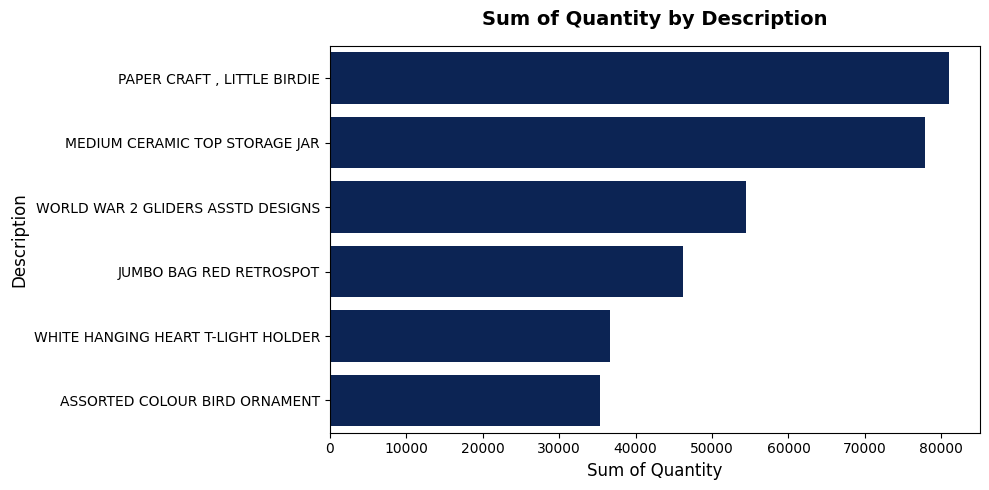

In [ ]:

top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(6).reset_index()


plt.figure(figsize=(10, 5))
sns.barplot(data=top_products, x='Quantity', y='Description', color='#002060')

plt.title('Sum of Quantity by Description', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Sum of Quantity', fontsize=12)
plt.ylabel('Description', fontsize=12)
plt.tight_layout()

# Save image for GitHub
plt.savefig('top_products_quantity.png', dpi=300)
plt.show()

In [ ]:
import plotly.express as px

country_sales = df.groupby('Country')['TotalAmount'].sum().reset_index()

# 2. Interactive Treemap using Plotly
fig = px.treemap(country_sales,
                 path=['Country'],
                 values='TotalAmount',
                 title='Sum of TotalAmount by Country',
                 color='TotalAmount',
                 color_continuous_scale='Blues')

fig.update_layout(title_font=dict(size=18, family='Arial', color='black'))


fig.write_html("country_sales_treemap.html")
fig.show()

In [5]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data load karna
df = pd.read_csv('cleaned_ecommerce.csv')

# 2. Descriptive Statistics (Mean, Median, Mode, Std Dev, Variance)
print("="*50)
print("1. DESCRIPTIVE STATISTICS")
print("="*50)
stats_summary = df[['Quantity', 'TotalAmount']].describe()

# Variance aur Mode alag se calculate karke add karenge
stats_summary.loc['variance'] = df[['Quantity', 'TotalAmount']].var()
stats_summary.loc['mode'] = df[['Quantity', 'TotalAmount']].mode().iloc[0]

print(stats_summary.round(2))

# 3. Skewness & Kurtosis (Shape of Distribution)
print("\n" + "="*50)
print("2. DISTRIBUTION SHAPE (SKEWNESS & KURTOSIS)")
print("="*50)
for col in ['Quantity', 'TotalAmount']:
    print(f"[{col}]")
    print(f"  Skewness : {stats.skew(df[col].dropna()):.2f}")
    print(f"  Kurtosis : {stats.kurtosis(df[col].dropna()):.2f}\n")

1. DESCRIPTIVE STATISTICS
           Quantity  TotalAmount
count     397884.00    397884.00
mean          12.99        22.40
std          179.33       309.07
min            1.00         0.00
25%            2.00         4.68
50%            6.00        11.80
75%           12.00        19.80
max        80995.00    168469.60
variance   32159.89     95524.91
mode           1.00        15.00

2. DISTRIBUTION SHAPE (SKEWNESS & KURTOSIS)
[Quantity]
  Skewness : 409.89
  Kurtosis : 178184.00

[TotalAmount]
  Skewness : 451.44
  Kurtosis : 232152.20



In [7]:
# --- HYPOTHESIS TESTING (T-TEST) ---
print("="*50)
print("3. INFERENTIAL STATISTICS (HYPOTHESIS TESTING)")
print("="*50)

# Splitting data into United Kingdom and Non-United Kingdom groups
uk_sales = df[df['Country'] == 'United Kingdom']['TotalAmount'].dropna()
non_uk_sales = df[df['Country'] != 'United Kingdom']['TotalAmount'].dropna()

print(f"UK Transactions Count: {len(uk_sales)}")
print(f"Non-UK Transactions Count: {len(non_uk_sales)}\n")

# Performing Independent Two-Sample T-Test (Welch's T-Test due to unequal variances)
t_stat, p_val = stats.ttest_ind(uk_sales, non_uk_sales, equal_var=False)

print(f"T-Statistic value : {t_stat:.4f}")
print(f"P-Value          : {p_val}")

# Checking statistical significance at Alpha = 0.05
alpha = 0.05
if p_val < alpha:
    print("\nResult: Reject the Null Hypothesis (Statistically Significant)")
    print("Insight: There is a significant difference in the average spending behavior between UK and Non-UK customers.")
else:
    print("\nResult: Fail to Reject the Null Hypothesis (Not Statistically Significant)")
    print("Insight: The average spending behavior between UK and Non-UK customers is statistically similar.")

3. INFERENTIAL STATISTICS (HYPOTHESIS TESTING)
UK Transactions Count: 354321
Non-UK Transactions Count: 43563

T-Statistic value : -23.4680
P-Value          : 1.1938265619894493e-121

Result: Reject the Null Hypothesis (Statistically Significant)
Insight: There is a significant difference in the average spending behavior between UK and Non-UK customers.


4. WEEKLY TIME SERIES ANALYSIS & ARIMA FORECASTING
Total Weekly Data Points Available: 54

Decomposing Weekly Time Series...


<Figure size 1000x600 with 0 Axes>

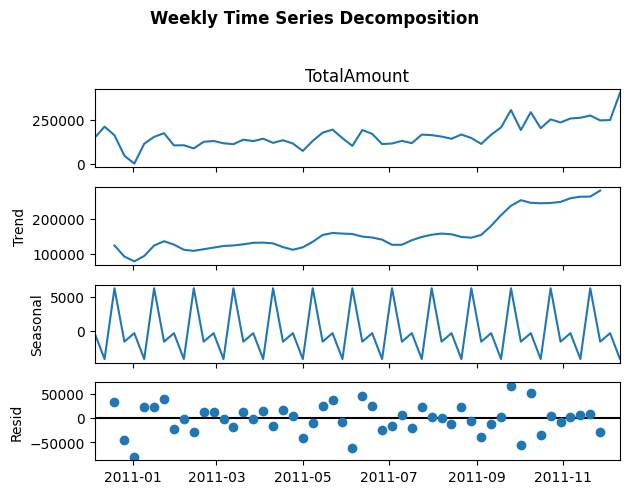


----------------------------------------
Applying Differencing to make data Stationary...
ADF Statistic after Differencing: -7.5932
p-value after Differencing       : 2.499590708027972e-11

Train size: 43 weeks, Test size: 11 weeks

Training ARIMA(1,1,1) Model...

--- Model Evaluation ---
Mean Absolute Error (MAE)  : 74065.00
Root Mean Squared Error (RMSE): 89888.91
Forecast Accuracy Score    : 73.85%


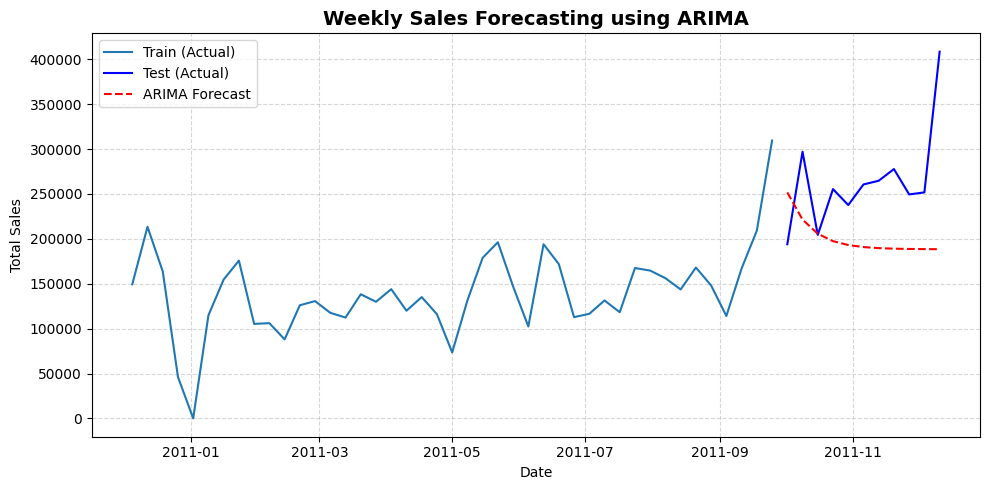

5. CUSTOMER SEGMENTATION USING K-MEANS CLUSTERING
Engineered RFM Features (First 5 Rows):
   CustomerID  Recency  Frequency  Monetary
0     12346.0      325          1  77183.60
1     12347.0        1          7   4310.00
2     12348.0       74          4   1797.24
3     12349.0       18          1   1757.55
4     12350.0      309          1    334.40

Training K-Means Model...

----------------------------------------
Cluster Profile Summary (Mean Values):
----------------------------------------
   Cluster  Recency  Frequency  Monetary  Customer_Count
0        0   246.11       1.58    631.42            1082
1        1    40.45       4.67   1855.94            3230
2        2     5.04      66.42  85904.35              26


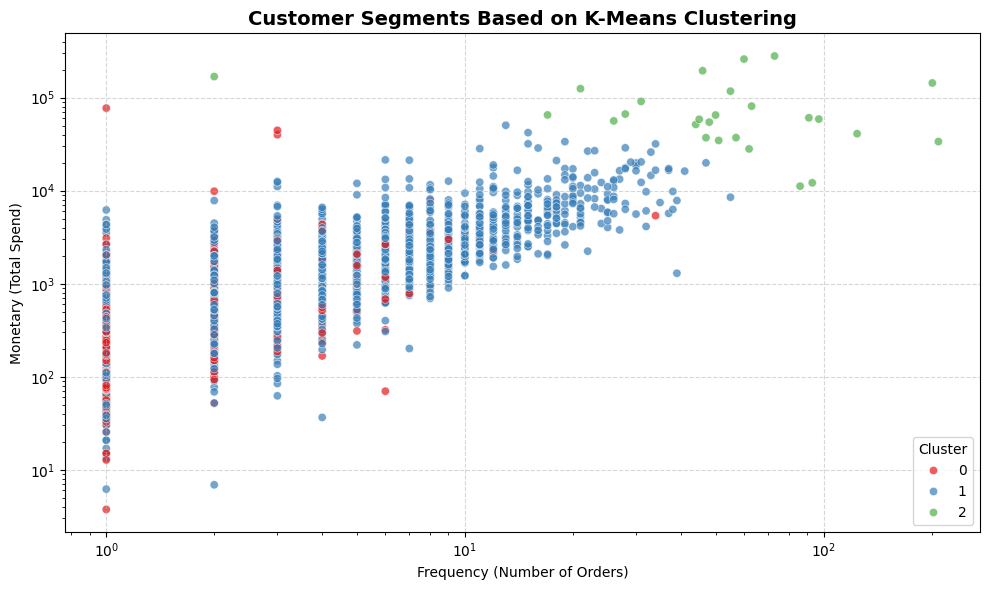

In [12]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

print("="*60)
print("5. CUSTOMER SEGMENTATION USING K-MEANS CLUSTERING")
print("="*60)

# 1. RFM Feature Engineering
# Calculate Latest Date in dataset to calculate Recency
latest_date = df['InvoiceDate'].max()

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (latest_date - x.max()).days, # Recency
    'InvoiceNo': 'nunique',                               # Frequency
    'TotalAmount': 'sum'                                  # Monetary
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']
print("Engineered RFM Features (First 5 Rows):")
print(rfm.head())

# 2. Scaling the Features (Crucial for K-Means)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

# 3. Applying K-Means Clustering (Setting K=3 for Low, Medium, High Value Segments)
print("\nTraining K-Means Model...")
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# 4. Analyzing the Profiles of Each Cluster
print("\n" + "-"*40)
print("Cluster Profile Summary (Mean Values):")
print("-"*40)
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'CustomerID': 'count'
}).rename(columns={'CustomerID': 'Customer_Count'}).reset_index()

print(cluster_profile.round(2))

# 5. Visualizing the Clusters (Scatter Plot: Frequency vs Monetary)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Cluster', palette='Set1', alpha=0.7)
plt.title('Customer Segments Based on K-Means Clustering', fontsize=14, fontweight='bold')
plt.xlabel('Frequency (Number of Orders)')
plt.ylabel('Monetary (Total Spend)')
plt.yscale('log') # Using log scale due to high extreme outliers found in Task 4.1
plt.xscale('log')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('customer_clusters.png', dpi=300)
plt.show()

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("="*60)
print("6. PREDICTIVE MODELING FOR CUSTOMER VALUE CLASS")
print("="*60)

# 1. Defining Target Variable
# Target = 1 if customer belongs to Cluster 1 or 2 (Active/High Value), Target = 0 if Cluster 0 (Low Value)
rfm['Is_High_Value'] = np.where(rfm['Cluster'].isin([1, 2]), 1, 0)

X = rfm[['Recency', 'Frequency']]
y = rfm['Is_High_Value']

# 2. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape : {X_test.shape}\n")

# 3. Training Logistic Regression
print("Training Logistic Regression Model...")
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# 4. Training Decision Tree Classifier
print("Training Decision Tree Model...")
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

# 5. Evaluation Function
def evaluate_model(predictions, model_name):
    print(f"\n--- {model_name} Performance ---")
    print(f"Accuracy  : {accuracy_score(y_test, predictions)*100:.2f}%")
    print(f"Precision : {precision_score(y_test, predictions)*100:.2f}%")
    print(f"Recall    : {recall_score(y_test, predictions)*100:.2f}%")
    print(f"F1-Score  : {f1_score(y_test, predictions)*100:.2f}%")

# Evaluate both models
evaluate_model(lr_preds, "Logistic Regression")
evaluate_model(dt_preds, "Decision Tree")

6. PREDICTIVE MODELING FOR CUSTOMER VALUE CLASS
Training Features Shape: (3470, 2)
Testing Features Shape : (868, 2)

Training Logistic Regression Model...
Training Decision Tree Model...

--- Logistic Regression Performance ---
Accuracy  : 99.88%
Precision : 99.84%
Recall    : 100.00%
F1-Score  : 99.92%

--- Decision Tree Performance ---
Accuracy  : 99.77%
Precision : 100.00%
Recall    : 99.69%
F1-Score  : 99.84%
